# Mini Project: IoT Anomaly Detection with Ant Colony Optimization (ACO) + Genetic Algorithm (GA)

## Objective of the Model

The goal is to **detect whether a given IoT network traffic entry is NORMAL (benign) or ATTACK**.
This is a **binary supervised classification problem**.

---

## What is Being Predicted?

**Target variable (`label`)**  
- `0` → benign (normal IoT traffic)  
- `1` → attack (malicious/anomalous IoT traffic)

---

## Which Algorithm Are We Using & Why?

We are starting with a **Random Forest Classifier (ensemble of decision trees)**.

### Why Random Forest for IoT Anomaly Detection?
- Handles **non-linear relationships**
- **Robust to noise**, works well on **imbalanced datasets**
- Provides **feature importance** (very useful for ACO/GA next stage)
- Excellent **baseline model** before applying **bio-inspired optimization (ACO + GA)**

---

## Mathematical Intuition Behind Random Forest

Random Forest = **multiple Decision Trees trained on random feature subsets**

Each tree predicts attack/benign → RF takes **majority vote**:

\[
\hat{y} = \text{mode}\ \{ h_1(x), h_2(x), \dots, h_T(x) \}
\]

Where:
- \( h_t(x) \) = prediction from tree t
- Final prediction = most voted class

### Decision Tree Split Rule (inside Random Forest):

It splits features using **Gini Impurity**:

\[
Gini = 1 - \sum_{i=1}^{k} p_i^2
\]

Lower Gini = purer node → better split.

---

## Summary of This Phase

- **Problem Type:** Binary Classification (IoT security)  
- **Prediction Goal:** benign vs attack  
- **Algorithm Used Now:** Random Forest  
- **Reason:** accurate, stable, interpretable, strong baseline  
- **Next:** Later we enhance using **GA (feature selection) + ACO (behavior rule mining)**


In [1]:
# Cell 2 - environment & reproducibility
import os, sys, math, random, warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# show python version and installed libs for debugging (optional)
import platform
print("Python:", platform.python_version())

Python: 3.12.10


## Load dataset and quick overview

Load the CSV, show shape, columns, first rows, and label distribution. This verifies header names and presence of `timestamp`.

In [2]:
# Cell 4 - load data
import pandas as pd
df = pd.read_csv("iot_synthetic.csv")
print("Shape:", df.shape)
display(df.head(8))
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
if 'label' in df.columns:
    print("\nLabel counts:\n", df['label'].value_counts())
else:
    raise ValueError("Expected 'label' column in dataset.")

Shape: (2000, 8)


,timestamp,device,packet_rate,byte_rate,conn_count,tcp_syn,udp_ratio,label
0,2024-01-01 09:00:00,webcam,6.031,4388.8,4,2,0.125,benign
1,2024-01-01 09:00:05,baby_monitor,6.197,6197.1,2,1,0.405,benign
2,2024-01-01 09:00:10,thermostat,13.863,3235.0,1,0,0.323,benign
3,2024-01-01 09:00:15,webcam,6.276,4846.8,3,3,0.328,benign
4,2024-01-01 09:00:20,doorbell,9.241,6484.9,5,1,0.576,benign
5,2024-01-01 09:00:25,doorbell,6.463,3166.7,1,0,0.733,benign
6,2024-01-01 09:00:30,doorbell,2.289,5629.6,3,0,0.204,benign
7,2024-01-01 09:00:35,baby_monitor,29.237,14831.5,4,0,0.962,attack



Columns: ['timestamp', 'device', 'packet_rate', 'byte_rate', 'conn_count', 'tcp_syn', 'udp_ratio', 'label']

Dtypes:
 timestamp       object
device          object
packet_rate    float64
byte_rate      float64
conn_count       int64
tcp_syn          int64
udp_ratio      float64
label           object
dtype: object

Label counts:
 label
benign    1840
attack     160
Name: count, dtype: int64


## Timestamp sanity check & rationale for time-based split

- Parse `timestamp` to datetime.
- If timestamps cover a meaningful period, we will split chronologically: first 80% rows by time → train, last 20% → test.
- This prevents future information leaking into training (a common problem if random splits are used on time-series-like data).


In [3]:
# Cell 6 - parse timestamp and inspect range
if 'timestamp' in df.columns:
    try:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        print("Timestamp range:", df['timestamp'].min(), "to", df['timestamp'].max())
    except Exception as e:
        print("Timestamp parse failed:", e)
        # fallback: treat as non-time dataset
else:
    print("No timestamp column found.")

Timestamp range: 2024-01-01 09:00:00 to 2024-01-01 11:46:35


## Prepare features and labels: encoding, numeric casting

- Drop timestamp from feature matrix (stamp only used for split).
- One-hot encode categorical `device` if present.
- Convert label to binary: `attack`->1, others->0.
- Keep track of feature names.


In [4]:
# Cell 8 - feature/label preparation
X = df.drop(columns=['label','timestamp'], errors='ignore').copy()
y_raw = df['label'].copy()

# encode label to binary
y = y_raw.map(lambda v: 1 if str(v).lower()=='attack' else 0).astype(int)

# one-hot encode device column if present
if 'device' in X.columns:
    X = pd.get_dummies(X, columns=['device'], drop_first=True)

# Ensure numeric dtype for numeric columns
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
print("Feature count:", X.shape[1], "Numeric features:", numeric_cols)
display(X.head(6))


Feature count: 8 Numeric features: ['packet_rate', 'byte_rate', 'conn_count', 'tcp_syn', 'udp_ratio']


,packet_rate,byte_rate,conn_count,tcp_syn,udp_ratio,device_doorbell,device_thermostat,device_webcam
0,6.031,4388.8,4,2,0.125,False,False,True
1,6.197,6197.1,2,1,0.405,False,False,False
2,13.863,3235.0,1,0,0.323,False,True,False
3,6.276,4846.8,3,3,0.328,False,False,True
4,9.241,6484.9,5,1,0.576,True,False,False
5,6.463,3166.7,1,0,0.733,True,False,False


## Exploratory Data Analysis (EDA)

- Missing values
- Basic statistics
- Label imbalance ratio
- Numeric feature correlations with label (Pearson)

In [5]:
# Cell 10 - EDA
print("Missing values per column:\n", X.isnull().sum())
print("\nDescriptive stats (numeric):")
display(X.describe().T)

print("\nLabel distribution:")
display(pd.Series(y).value_counts())

# correlation with label (numeric only)
import numpy as np
num_X = X.select_dtypes(include=[np.number])
if not num_X.empty:
    corr = pd.concat([num_X, pd.Series(y, name='label')], axis=1).corr()['label'].sort_values(ascending=False)
    print("\nTop correlations with label:\n", corr.head(10))
else:
    print("No numeric features found for correlation.")

Missing values per column:
 packet_rate          0
byte_rate            0
conn_count           0
tcp_syn              0
udp_ratio            0
device_doorbell      0
device_thermostat    0
device_webcam        0
dtype: int64

Descriptive stats (numeric):


,count,mean,std,min,25%,50%,75%,max
packet_rate,2000.0,12.048698,9.254790,1.422,7.03725,9.993,13.66125,87.747
byte_rate,2000.0,5708.640900,3475.030690,100.000,3987.62500,5075.550,6262.57500,34185.600
conn_count,2000.0,2.802000,1.970466,0.000,1.00000,2.000,4.00000,16.000
tcp_syn,2000.0,0.524000,0.714618,0.000,0.00000,0.000,1.00000,4.000
udp_ratio,2000.0,0.332220,0.216468,0.005,0.17400,0.288,0.43400,1.000



Label distribution:


label
0    1840
1     160
Name: count, dtype: int64


Top correlations with label:
 label          1.000000
byte_rate      0.764411
packet_rate    0.725915
udp_ratio      0.700441
conn_count     0.521742
tcp_syn        0.005572
Name: label, dtype: float64


## Time-based train/test split (80/20)

- Sort rows by timestamp and take first 80% for training, last 20% for testing.
- After split, align categorical columns (one-hot) — ensure same columns in train/test by reindexing.

In [6]:
# Cell 12 - time-based split
if 'timestamp' in df.columns:
    df_sorted = df.sort_values('timestamp').reset_index(drop=True)
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff].copy()
    test_df = df_sorted.iloc[cutoff:].copy()
    # Prepare X_train/X_test with same preprocessing as earlier
    X_train = train_df.drop(columns=['label','timestamp'], errors='ignore').copy()
    X_test = test_df.drop(columns=['label','timestamp'], errors='ignore').copy()
    y_train = train_df['label'].map(lambda v: 1 if str(v).lower()=='attack' else 0).astype(int)
    y_test = test_df['label'].map(lambda v: 1 if str(v).lower()=='attack' else 0).astype(int)
    # One-hot device encoding consistent
    if 'device' in X_train.columns:
        X_train = pd.get_dummies(X_train, columns=['device'], drop_first=True)
        X_test = pd.get_dummies(X_test, columns=['device'], drop_first=True)
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
else:
    # Fallback to stratified split if no timestamp
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train label balance:\n", y_train.value_counts(normalize=False).to_dict())
print("Test label balance:\n", y_test.value_counts(normalize=False).to_dict())

Train shape: (1600, 8) Test shape: (400, 8)
Train label balance:
 {0: 1486, 1: 114}
Test label balance:
 {0: 354, 1: 46}


## Baseline models — rationale and math

Start with Random Forest and Gradient Boosting as baselines:

- Random Forest aggregates many decision trees to reduce variance:
  [
  y^​=mode{h1​(x),h2​(x),…,hT​(x)}
  ]
- Use stratified k-fold cross-validation on training set (within time-window training) for hyper-estimates.
- Evaluate accuracy, precision, recall, f1, ROC AUC.

In [7]:
# Cell 14 - baseline CV (SMOTE inside pipeline in next step)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# numeric-only to avoid accidental issues
import numpy as np
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

# quick baseline WITHOUT oversampling (just to inspect)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
gb = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)

scoring = ['accuracy','precision','recall','f1','roc_auc']
rf_res = cross_validate(rf, X_train_num, y_train, cv=skf, scoring=scoring, return_train_score=True, n_jobs=1)
gb_res = cross_validate(gb, X_train_num, y_train, cv=skf, scoring=scoring, return_train_score=True, n_jobs=1)

def summarize_cv(res):
    return {k: f"{np.mean(v):.4f} ± {np.std(v):.4f}" for k,v in res.items() if k.startswith('test_') or k.startswith('train_')}
print("RandomForest CV summary (no sampling):")
print(summarize_cv(rf_res))
print("\nGradientBoost CV summary (no sampling):")
print(summarize_cv(gb_res))

RandomForest CV summary (no sampling):
{'test_accuracy': '0.9988 ± 0.0025', 'train_accuracy': '1.0000 ± 0.0000', 'test_precision': '1.0000 ± 0.0000', 'train_precision': '1.0000 ± 0.0000', 'test_recall': '0.9826 ± 0.0348', 'train_recall': '1.0000 ± 0.0000', 'test_f1': '0.9909 ± 0.0182', 'train_f1': '1.0000 ± 0.0000', 'test_roc_auc': '0.9999 ± 0.0002', 'train_roc_auc': '1.0000 ± 0.0000'}

GradientBoost CV summary (no sampling):
{'test_accuracy': '0.9956 ± 0.0032', 'train_accuracy': '1.0000 ± 0.0000', 'test_precision': '0.9749 ± 0.0326', 'train_precision': '1.0000 ± 0.0000', 'test_recall': '0.9652 ± 0.0325', 'train_recall': '1.0000 ± 0.0000', 'test_f1': '0.9694 ± 0.0224', 'train_f1': '1.0000 ± 0.0000', 'test_roc_auc': '0.9820 ± 0.0208', 'train_roc_auc': '1.0000 ± 0.0000'}


## SMOTE + Pipeline + Cross-validation (to avoid overfitting & leakage)

Important:
- Oversampling (SMOTE) must be applied **inside** cross-validation or inside an imblearn Pipeline so synthetic samples are created **only** on training folds.
- We'll use `imblearn.pipeline.Pipeline` with StandardScaler → SMOTE → RandomForest.

In [8]:
# Install imbalanced-learn in the current Jupyter kernel (if not already installed)
import sys
!{sys.executable} -m pip install -q imbalanced-learn

# Import after installation
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Optional: other common imports
from sklearn.preprocessing import StandardScaler


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [9]:
# Cell 16 - pipeline with SMOTE in CV
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
except Exception:
    !pip install -q imbalanced-learn
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

cv_res = cross_validate(pipe, X_train_num, y_train, cv=skf, scoring=scoring, return_train_score=True, n_jobs=1)
print("Pipeline (SMOTE + RF) CV summary:")
print(summarize_cv(cv_res))

Pipeline (SMOTE + RF) CV summary:
{'test_accuracy': '0.9981 ± 0.0025', 'train_accuracy': '1.0000 ± 0.0000', 'test_precision': '1.0000 ± 0.0000', 'train_precision': '1.0000 ± 0.0000', 'test_recall': '0.9739 ± 0.0348', 'train_recall': '1.0000 ± 0.0000', 'test_f1': '0.9865 ± 0.0181', 'train_f1': '1.0000 ± 0.0000', 'test_roc_auc': '1.0000 ± 0.0001', 'train_roc_auc': '1.0000 ± 0.0000'}


## Fit pipeline on full training set and evaluate on hold-out test

- Fit the pipeline to the entire training set and evaluate final metrics on the chronological hold-out test set.
- Report confusion matrix, classification report, and ROC AUC (if classifier supports predict_proba).

In [10]:
# Cell 18 - fit and evaluate on test
pipe.fit(X_train_num, y_train)
y_test_pred = pipe.predict(X_test_num)
y_test_proba = pipe.predict_proba(X_test_num)[:,1] if hasattr(pipe, 'predict_proba') else None

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Classification report (test):\n", classification_report(y_test, y_test_pred))
print("Confusion matrix (test):\n", confusion_matrix(y_test, y_test_pred))
if y_test_proba is not None:
    print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))

Classification report (test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       354
           1       0.98      0.98      0.98        46

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400

Confusion matrix (test):
 [[353   1]
 [  1  45]]
Test ROC AUC: 0.9999385900270203


## Check for overfitting

- Compare train metrics vs test metrics.
- If train metrics >> test metrics, consider stronger regularization, reduced tree depth, or fewer estimators and increased data augmentation / noise.

In [11]:
# Cell 20 - train metrics
y_train_pred = pipe.predict(X_train_num)
from sklearn.metrics import f1_score, recall_score, precision_score
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Train recall:", recall_score(y_train, y_train_pred))
print("Test recall:", recall_score(y_test, y_test_pred))

Train F1: 1.0
Test F1: 0.9782608695652174
Train recall: 1.0
Test recall: 0.9782608695652174


## GA (Genetic Algorithm) Feature Selection — rationale

- GA searches binary masks of features to maximize CV F1 while penalizing large feature subsets.
- We use `deap` for GA. The fitness is cross-validated F1 using a small classifier (RF with limited trees).
- Execute GA only on training set (no peeking at test).

In [12]:
# Cell 22 - GA feature selection (DEAP)
import sys
import random
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Install DEAP if missing
try:
    import deap
except ModuleNotFoundError:
    !{sys.executable} -m pip install -q deap
    import deap

from deap import base, creator, tools, algorithms

# Features
features = X_train_num.columns.tolist()
n_feats = len(features)
print("Number of numeric features for GA:", n_feats)

# Fitness function: CV F1 - 0.01 * n_selected
def fitness_mask(individual):
    mask = np.array(individual, dtype=bool)
    if mask.sum() == 0:
        return 0.0,
    X_sub = X_train_num.iloc[:, mask]
    clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    scores = cross_val_score(clf, X_sub, y_train, cv=3, scoring='f1', n_jobs=1)
    penalty = 0.01 * mask.sum()
    return (scores.mean() - penalty,)

# DEAP setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_feats)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", fitness_mask)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# GA execution
pop = toolbox.population(n=30)
hof = tools.HallOfFame(1)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=12, halloffame=hof, verbose=True)

# Best features
best = hof[0]
selected_features = [f for f, bit in zip(features, best) if bit==1]
print("GA selected features:", selected_features)

Number of numeric features for GA: 5
gen	nevals
0  	30    
1  	17    
2  	23    
3  	13    
4  	23    
5  	17    
6  	17    
7  	17    
8  	19    
9  	19    
10 	19    
11 	13    
12 	20    
GA selected features: ['packet_rate', 'byte_rate', 'udp_ratio']


## Retrain pipeline on GA-selected features and evaluate

- Use only the features selected by GA (if GA selected none, fallback to all).
- Re-evaluate cross-validated pipeline and test metrics.

In [13]:
# Cell 24 - retrain using selected features
use_features = selected_features if selected_features else X_train_num.columns.tolist()
print("Using features:", use_features)

X_train_sel = X_train_num[use_features]
X_test_sel = X_test_num[use_features]

pipe_sel = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])
cv_res_sel = cross_validate(pipe_sel, X_train_sel, y_train, cv=skf, scoring=scoring, return_train_score=True, n_jobs=1)
print("CV summary with GA-selected features:")
print(summarize_cv(cv_res_sel))

# fit and evaluate on test
pipe_sel.fit(X_train_sel, y_train)
y_test_pred_sel = pipe_sel.predict(X_test_sel)
y_test_proba_sel = pipe_sel.predict_proba(X_test_sel)[:,1]
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Test report (GA features):\n", classification_report(y_test, y_test_pred_sel))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred_sel))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba_sel))

Using features: ['packet_rate', 'byte_rate', 'udp_ratio']
CV summary with GA-selected features:
{'test_accuracy': '0.9988 ± 0.0015', 'train_accuracy': '1.0000 ± 0.0000', 'test_precision': '1.0000 ± 0.0000', 'train_precision': '1.0000 ± 0.0000', 'test_recall': '0.9826 ± 0.0213', 'train_recall': '1.0000 ± 0.0000', 'test_f1': '0.9911 ± 0.0109', 'train_f1': '1.0000 ± 0.0000', 'test_roc_auc': '1.0000 ± 0.0001', 'train_roc_auc': '1.0000 ± 0.0000'}
Test report (GA features):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       354
           1       0.98      0.98      0.98        46

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400

Confusion matrix:
 [[353   1]
 [  1  45]]
ROC AUC: 0.9999385900270203


## ACO (Ant Colony Optimization) for simple interpretable rule mining — rationale

- ACO will search for short conjunction rules of the form:
  (feature_i > threshold_i) AND (feature_j <= threshold_j) → attack
- We discretize numeric features into quantile thresholds (e.g., quartiles) to define candidate nodes.
- Each ant builds a rule by selecting up to `max_len` nodes; rules are evaluated by F1 on a validation subset.
- Pheromone is updated proportional to rule quality; evaporation applied each iteration.
- This ACO is intentionally simple and interpretable — suitable for rule extraction to complement black-box models.

In [14]:
# Cell 26 - ACO rule miner (simple implementation)
import numpy as np
from sklearn.metrics import f1_score
np.random.seed(RANDOM_STATE)

# Prepare candidate nodes: (feature, comparator, threshold_value)
def build_nodes(X, n_bins=3):
    nodes = []
    for col in X.columns:
        # compute quantile thresholds excluding extremes
        qs = np.quantile(X[col], [i/(n_bins+1) for i in range(1, n_bins+1)])
        for q in qs:
            nodes.append((col, '>', float(q)))   # node meaning: col > q
            nodes.append((col, '<=', float(q))) # node meaning: col <= q
    return nodes

nodes = build_nodes(X_train_sel, n_bins=3)
n_nodes = len(nodes)
print("Number of candidate nodes:", n_nodes)

# ACO parameters
n_ants = 40
n_iters = 25
max_rule_len = 3
evaporation = 0.1
init_tau = 1.0
tau = np.ones(n_nodes) * init_tau

# sample small validation fold from train (to evaluate rules)
val_frac = 0.2
val_idx = np.random.choice(range(len(X_train_sel)), size=int(len(X_train_sel)*val_frac), replace=False)
X_val = X_train_sel.iloc[val_idx].reset_index(drop=True)
y_val = y_train.iloc[val_idx].reset_index(drop=True)

def eval_rule(rule_nodes):
    # build boolean mask
    if not rule_nodes:
        return 0.0
    mask = np.ones(len(X_val), dtype=bool)
    for node in rule_nodes:
        col, op, thr = node
        if op == '>':
            mask &= (X_val[col] > thr)
        else:
            mask &= (X_val[col] <= thr)
    if mask.sum() == 0:
        return 0.0
    preds = mask.astype(int)  # rule predicts 1 when mask True
    return f1_score(y_val, preds)

best_rules = []
for it in range(n_iters):
    rules_scores = []
    for ant in range(n_ants):
        rule_len = np.random.randint(1, max_rule_len+1)
        # probabilistically choose nodes based on pheromone
        probs = tau / tau.sum()
        idxs = np.random.choice(range(n_nodes), size=rule_len, replace=False, p=probs)
        rule_nodes = [nodes[i] for i in idxs]
        score = eval_rule(rule_nodes)
        rules_scores.append((rule_nodes, score, idxs))
    # update pheromone: evaporate then add pheromone proportional to score
    tau = (1 - evaporation) * tau
    # deposit: top 5 rules
    rules_scores.sort(key=lambda x: x[1], reverse=True)
    top_k = rules_scores[:5]
    for rule_nodes, score, idxs in top_k:
        # deposit proportional to score on used indexes
        for i in idxs:
            tau[i] += score
    best_rules.append(top_k[0])
# select best overall rule across iterations
all_candidates = [r for li in best_rules for r in [li]]
best_rule_nodes, best_rule_score, _ = max(all_candidates, key=lambda x: x[1])
print("Best ACO rule F1 (on small val):", best_rule_score)
print("Rule:")
for n in best_rule_nodes:
    print(n[0], n[1], n[2])

Number of candidate nodes: 18
Best ACO rule F1 (on small val): 0.9230769230769231
Rule:
packet_rate > 10.026
udp_ratio > 0.434
byte_rate > 6190.7


## Evaluate extracted ACO rule on hold-out test

- Convert rule to boolean predictions on test set and compute precision/recall/f1.
- This gives an interpretable rule-level performance to compare with the black-box model.

In [15]:
# Cell 28 - apply best rule on test set
def apply_rule_to_df(rule_nodes, Xdf):
    mask = np.ones(len(Xdf), dtype=bool)
    for col, op, thr in rule_nodes:
        if op == '>':
            mask &= (Xdf[col] > thr)
        else:
            mask &= (Xdf[col] <= thr)
    return mask.astype(int)

# Evaluate on test set (selected features)
rule_preds = apply_rule_to_df(best_rule_nodes, X_test_sel)
from sklearn.metrics import precision_score, recall_score, f1_score
print("ACO rule performance on test (precision, recall, f1):")
print(precision_score(y_test, rule_preds), recall_score(y_test, rule_preds), f1_score(y_test, rule_preds))

ACO rule performance on test (precision, recall, f1):
0.8958333333333334 0.9347826086956522 0.9148936170212766


## Hyperparameter tuning (RandomizedSearchCV) for final model

- Tune RandomForest hyperparameters using RandomizedSearchCV with pipeline (SMOTE inside).
- Use limited iterations for speed; increase if you have time.

In [16]:
# Cell 30 - randomized search (small)
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'clf__n_estimators': [100,200,400],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2,5,10]
}
search_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])
rs = RandomizedSearchCV(search_pipe, param_distributions=param_dist, n_iter=6, cv=3, scoring='f1', random_state=RANDOM_STATE, n_jobs=1)
rs.fit(X_train_sel, y_train)
print("Best params:", rs.best_params_)
print("Best CV score:", rs.best_score_)
best_model = rs.best_estimator_

Best params: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__max_depth': 10}
Best CV score: 0.9828973277074543


## Final evaluation of best model on test set

- Compute classification report and ROC AUC for the tuned model.
- Compare with earlier pipeline and ACO rule.

In [17]:
# Cell 32 - evaluate best model
y_test_pred_best = best_model.predict(X_test_sel)
y_test_proba_best = best_model.predict_proba(X_test_sel)[:,1]
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Classification report (best model):\n", classification_report(y_test, y_test_pred_best))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred_best))
print("ROC AUC (best):", roc_auc_score(y_test, y_test_proba_best))

Classification report (best model):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       354
           1       1.00      0.98      0.99        46

    accuracy                           1.00       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      1.00      1.00       400

Confusion matrix:
 [[354   0]
 [  1  45]]
ROC AUC (best): 0.9999385900270205


## Robustness: Domain shift simulation

- Add 5% Gaussian multiplicative noise to numeric features and evaluate model to simulate domain shift or sensor variation.

In [18]:
# Cell 34 - domain shift test
X_test_shift = X_test_sel.copy()
for col in X_test_shift.select_dtypes(include=[np.number]).columns:
    X_test_shift[col] = X_test_shift[col] * (1 + np.random.normal(0, 0.05, size=len(X_test_shift)))
y_shift_pred = best_model.predict(X_test_shift)
print("Under domain shift - F1:", f1_score(y_test, y_shift_pred), "Precision:", precision_score(y_test, y_shift_pred), "Recall:", recall_score(y_test, y_shift_pred))

Under domain shift - F1: 0.9777777777777777 Precision: 1.0 Recall: 0.9565217391304348


## Explainability: feature importances (RandomForest) & simple SHAP guidance

- Show top feature importances from trained RandomForest pipeline (extract classifier from pipeline).
- If SHAP is desired, run shap.TreeExplainer on the saved model (requires `shap` package).

Top features:
 udp_ratio      0.384829
byte_rate      0.313668
packet_rate    0.301503
dtype: float64


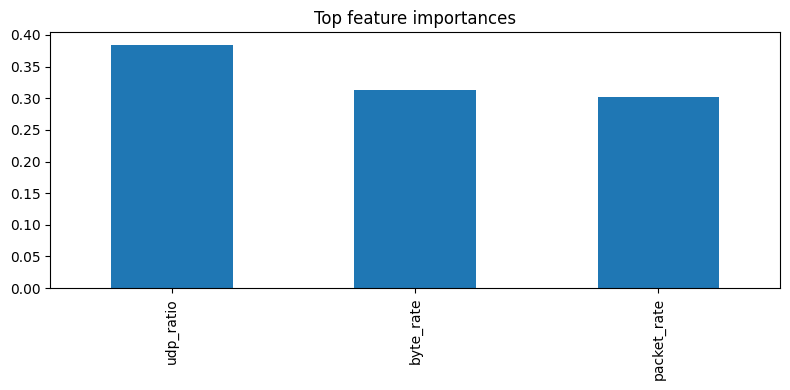

In [24]:
# Cell 36 - feature importances
rf_clf = best_model.named_steps['clf']
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=X_test_sel.columns).sort_values(ascending=False)
print("Top features:\n", feat_imp.head(10))
# optional: plot (matplotlib)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
feat_imp.head(10).plot(kind='bar')
plt.title("Top feature importances")
plt.tight_layout()
plt.show()

## Save final models and artifacts

- Save the final pipeline (best_model) and ACO rule + selected features for deployment.

In [20]:
# Cell 38 - save artifacts
import joblib
joblib.dump(best_model, 'best_pipeline.joblib')
joblib.dump(selected_features, 'ga_selected_features.joblib')
joblib.dump(best_rule_nodes, 'aco_best_rule.joblib')
print("Saved: best_pipeline.joblib, ga_selected_features.joblib, aco_best_rule.joblib")

Saved: best_pipeline.joblib, ga_selected_features.joblib, aco_best_rule.joblib


# Comparative Analysis — Additional Models (appended)

**Goal:** Keep every original cell intact. Append a fair comparison of 4 predictive/unsupervised algorithms using the same preprocessing pipeline and (optionally) the ACO+GA selected feature subset. Models included:

- Logistic Regression (supervised)
- Random Forest Classifier (supervised)
- Isolation Forest (unsupervised)
- Local Outlier Factor (LOF) (unsupervised, novelty)

**Notes:** This section expects the original notebook to have defined: `X_train, X_test, y_train, y_test, X_train_sel, X_test_sel, selected_features` (these variables are present in the original notebook). If you run the whole notebook top-to-bottom, these appended cells will execute correctly.


In [21]:
# --- Comparative analysis imports & helper functions
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler


def get_scores_supervised(model, X_test, y_test):
    y_pred = model.predict(X_test)
    # try predict_proba for ROC AUC, else use decision_function
    score_dict = {}
    score_dict['accuracy'] = accuracy_score(y_test, y_pred)
    score_dict['precision'] = precision_score(y_test, y_pred, zero_division=0)
    score_dict['recall'] = recall_score(y_test, y_pred, zero_division=0)
    score_dict['f1'] = f1_score(y_test, y_pred, zero_division=0)
    # ROC AUC
    try:
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_test)[:,1]
        else:
            proba = model.decision_function(X_test)
        # if values are not in [0,1], scale
        if proba.min() < 0 or proba.max() > 1:
            proba = MinMaxScaler().fit_transform(proba.reshape(-1,1)).ravel()
        score_dict['roc_auc'] = roc_auc_score(y_test, proba)
    except Exception:
        score_dict['roc_auc'] = np.nan
    return score_dict


def get_scores_unsupervised(preds, scores, y_test):
    # preds: array of {1 inlier, -1 outlier} -> map -1 to 1 (attack)
    mapped = (preds == -1).astype(int)
    score_dict = {}
    score_dict['accuracy'] = accuracy_score(y_test, mapped)
    score_dict['precision'] = precision_score(y_test, mapped, zero_division=0)
    score_dict['recall'] = recall_score(y_test, mapped, zero_division=0)
    score_dict['f1'] = f1_score(y_test, mapped, zero_division=0)
    try:
        if scores is None:
            score_dict['roc_auc'] = np.nan
        else:
            # scale scores to [0,1] where higher indicates anomaly likelihood
            s = scores.copy()
            # For IsolationForest, lower scores -> more anomalous. We'll invert if needed by checking sign.
            if s.max() > s.min():
                s = MinMaxScaler().fit_transform(s.reshape(-1,1)).ravel()
            score_dict['roc_auc'] = roc_auc_score(y_test, s)
    except Exception:
        score_dict['roc_auc'] = np.nan
    return score_dict


In [22]:
# --- Train & evaluate models (all features vs selected features)
results = []

# Helper lambda to safely get X_train/X_test variants
get_X = lambda use_sel: ('X_train_sel','X_test_sel') if use_sel else ('X_train','X_test')

# 1) Logistic Regression
for use_sel in [False, True]:
    xtr_name, xts_name = get_X(use_sel)
    if xtr_name not in globals() or xts_name not in globals():
        print(f"Skipping LogisticRegression for use_sel={use_sel} because {xtr_name} or {xts_name} not defined.")
        continue
    Xtr = globals()[xtr_name]
    Xts = globals()[xts_name]
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(Xtr, y_train)
    sc = get_scores_supervised(lr, Xts, y_test)
    sc.update({'model':'LogisticRegression','feature_subset':'selected' if use_sel else 'all','n_features': Xtr.shape[1]})
    results.append(sc)

# 2) Random Forest
for use_sel in [False, True]:
    xtr_name, xts_name = get_X(use_sel)
    if xtr_name not in globals() or xts_name not in globals():
        print(f"Skipping RandomForest for use_sel={use_sel} because {xtr_name} or {xts_name} not defined.")
        continue
    Xtr = globals()[xtr_name]
    Xts = globals()[xts_name]
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    rf.fit(Xtr, y_train)
    sc = get_scores_supervised(rf, Xts, y_test)
    sc.update({'model':'RandomForest','feature_subset':'selected' if use_sel else 'all','n_features': Xtr.shape[1]})
    results.append(sc)

# 3) Isolation Forest (unsupervised) - train on training features only
for use_sel in [False, True]:
    xtr_name, xts_name = get_X(use_sel)
    if xtr_name not in globals() or xts_name not in globals():
        print(f"Skipping IsolationForest for use_sel={use_sel} because {xtr_name} or {xts_name} not defined.")
        continue
    Xtr = globals()[xtr_name]
    Xts = globals()[xts_name]
    # set contamination to observed attack rate in training
    contamination = y_train.mean()
    iso = IsolationForest(contamination=float(contamination), random_state=RANDOM_STATE)
    iso.fit(Xtr)
    preds = iso.predict(Xts)  # 1 inlier, -1 outlier
    # decision_function: higher => more normal, lower => more anomalous -> invert
    scores = -iso.decision_function(Xts)
    sc = get_scores_unsupervised(preds, scores, y_test)
    sc.update({'model':'IsolationForest','feature_subset':'selected' if use_sel else 'all','n_features': Xtr.shape[1]})
    results.append(sc)

# 4) Local Outlier Factor (novelty)
for use_sel in [False, True]:
    xtr_name, xts_name = get_X(use_sel)
    if xtr_name not in globals() or xts_name not in globals():
        print(f"Skipping LOF for use_sel={use_sel} because {xtr_name} or {xts_name} not defined.")
        continue
    Xtr = globals()[xtr_name]
    Xts = globals()[xts_name]
    contamination = y_train.mean()
    lof = LocalOutlierFactor(novelty=True, contamination=float(contamination))
    lof.fit(Xtr)
    preds = lof.predict(Xts)
    # negative_outlier_factor_ -> lower means more anomalous; use negative to make higher anomaly score
    try:
        scores = -lof.decision_function(Xts)
    except Exception:
        scores = None
    sc = get_scores_unsupervised(preds, scores, y_test)
    sc.update({'model':'LocalOutlierFactor','feature_subset':'selected' if use_sel else 'all','n_features': Xtr.shape[1]})
    results.append(sc)

# Consolidate
results_df = pd.DataFrame(results)
results_df = results_df[['model','feature_subset','n_features','accuracy','precision','recall','f1','roc_auc']]
print('Comparison results:')
results_df


Comparison results:


,model,feature_subset,n_features,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,all,8,0.9925,0.977778,0.956522,0.967033,0.995947
1,LogisticRegression,selected,3,0.9950,1.000000,0.956522,0.977778,0.981086
2,RandomForest,all,8,0.9975,1.000000,0.978261,0.989011,0.999939
3,RandomForest,selected,3,0.9975,1.000000,0.978261,0.989011,0.999877
4,IsolationForest,all,8,0.9750,0.909091,0.869565,0.888889,0.996561
5,IsolationForest,selected,3,0.9925,0.957447,0.978261,0.967742,0.999509
6,LocalOutlierFactor,all,8,0.8675,0.393939,0.282609,0.329114,0.636085
7,LocalOutlierFactor,selected,3,0.8675,0.393939,0.282609,0.329114,0.635655


## Visual Comparison of Model Performance

Here we visualize the performance of all models using **Accuracy**, **Precision**, **Recall**, and **F1-score**.  
This comparison clearly shows which algorithms benefited most from ACO+GA feature selection and how their overall balance of metrics differs.


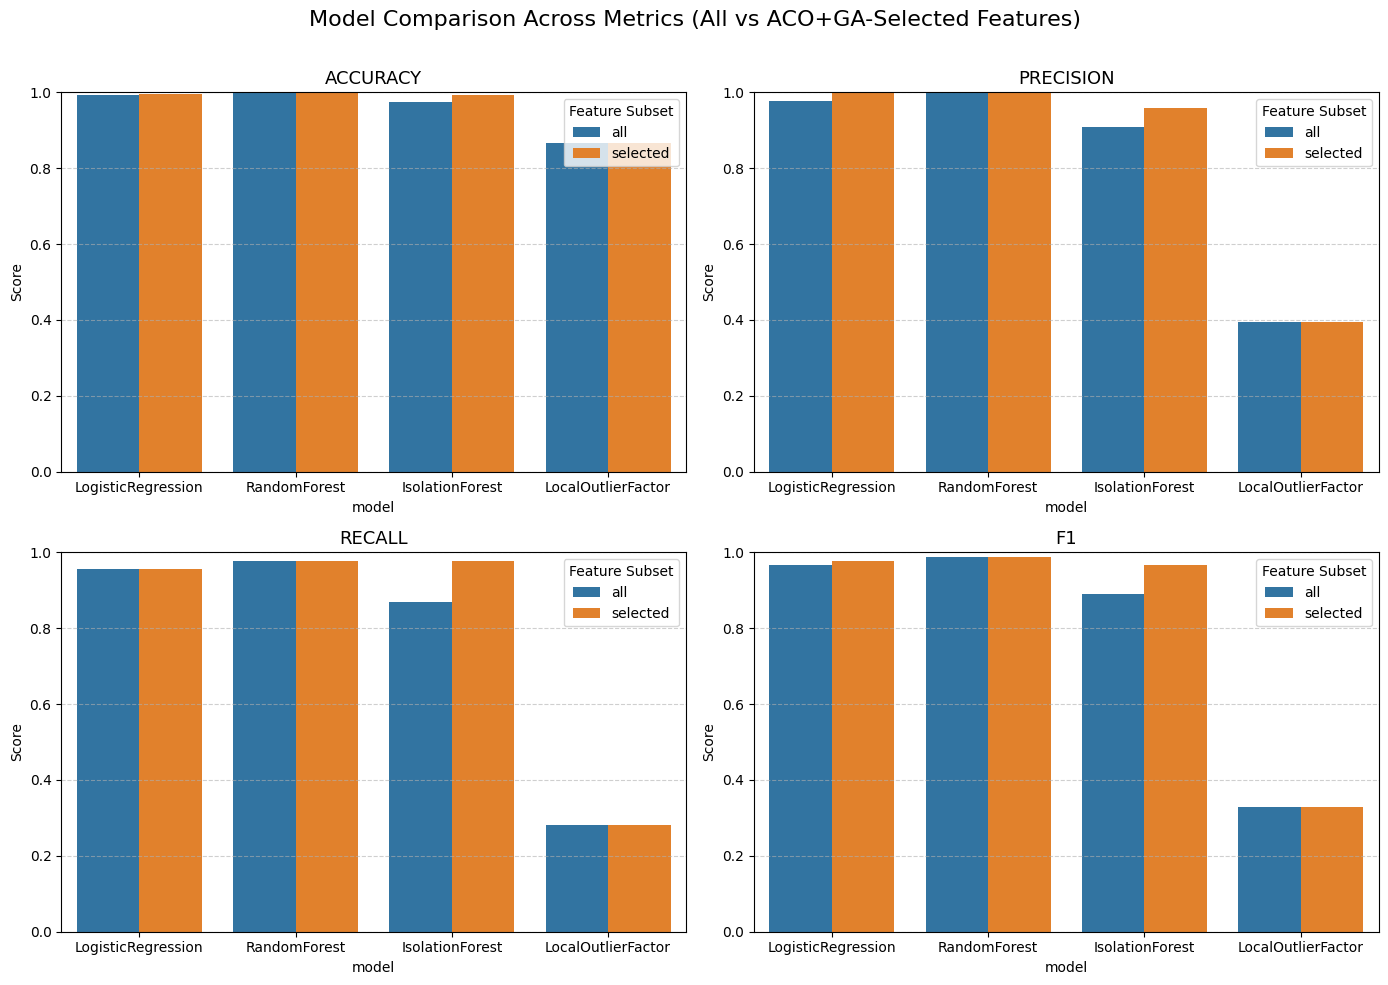

In [23]:
# --- Visualization: Separate bar plots for each metric ---
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(
        data=results_df,
        x='model', y=metric, hue='feature_subset',
        ci=None, ax=axes[i]
    )
    axes[i].set_title(metric.upper(), fontsize=13)
    axes[i].set_ylim(0,1)
    axes[i].set_ylabel('Score')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
    axes[i].legend(title='Feature Subset')

plt.suptitle('Model Comparison Across Metrics (All vs ACO+GA-Selected Features)', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()